In [2]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
import matplotlib
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.ndimage.filters as filters
# import nt2
import tqdm
import joblib
# %matplotlib widget
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})
fs = 15
fstick = 12


def smooth( x, window_len=61, window='hanning', axis = -1):
    return filters.convolve1d(x, np.ones(window_len)/window_len, axis=axis)

datafolder = '/travail/xgong/test_separate/output/mi25-Unmag'

datafolder = '/travail/xgong/test_separate/output/mi25-MA400_lrbound'
import re

match = re.search(r'mi(\d+)', datafolder)
if match:
    mi = float(match.group(1))
    print(mi)
else:
    print("no mi")

os.system('ls '+ os.path.join(datafolder, 'particles/partic*h5') + ' > ' + os.path.join(datafolder, 'filelist_prtl.txt'))
with open(os.path.join(datafolder, 'filelist_prtl.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))


os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.join(datafolder, 'filelist_flds.txt')) as f:
    files_fld = f.readlines()
    for i in range(len(files_fld)):
        files_fld[i] = files_fld[i].strip()
# print(len(files))
# %matplotlib widget

25.0
400


In [3]:
file = h5py.File(files[-1])['Step0']
idx = np.argsort(np.sqrt(np.array(file['pU1_2'])**2
                             +np.array(file['pU2_2'])**2
                             +np.array(file['pU3_2'])**2))

# idx = np.argsort(file['pX1_2'])


ids = np.array(file['pIDX_2'])[idx[-2000:-1]]
# print(ids)
file = h5py.File(files[-1])['Step0']
print(file.keys())
t = []
x = []
e = []

def extract(filename, keys, ids):
    try:
        file = h5py.File(filename)['Step0']
        ID = np.array(file['pIDX_2'])
    except KeyError:datafolder = "/travail/xgong/test_separate/output/mi25-Unmag/"
    
    id2loc = {pid: i for i, pid in enumerate(ID)}

    quants = [np.array(file['Time'])]

    for key in keys:
        if key == "vel":
            vel_all = np.sqrt(
                (np.array(file['pU1_2'])+0.1/4)**2 +
                np.array(file['pU2_2'])**2 +
                np.array(file['pU3_2'])**2
            )
            arr = np.zeros(len(ids))
            for j, pid in enumerate(ids):
                if pid in id2loc:
                    arr[j] = vel_all[id2loc[pid]]
            quants.append(arr)
        else:
            data_all = np.array(file[key])
            arr = np.zeros(len(ids)) * np.nan
            for j, pid in enumerate(ids):
                if pid in id2loc:
                    arr[j] = data_all[id2loc[pid]]
            quants.append(arr)

    return quants



results = joblib.Parallel(n_jobs=8)(
    joblib.delayed(extract)(file, ['pX1_2','vel'], ids) for file in tqdm.tqdm(files[:])
)

for res in results:
    t.append(res[0])
    x.append(res[1])
    e.append(res[2])
t = np.array(t)
x = np.array(x)
e = np.array(e)


<KeysViewHDF5 ['Step', 'Time', 'pIDX_1', 'pIDX_2', 'pPLDI0_1', 'pPLDI0_2', 'pPLDI1_1', 'pPLDI1_2', 'pPLDR0_1', 'pPLDR0_2', 'pU1_1', 'pU1_2', 'pU2_1', 'pU2_2', 'pU3_1', 'pU3_2', 'pW_1', 'pW_2', 'pX1_1', 'pX1_2']>


  2%|▏         | 8/400 [00:00<00:05, 74.85it/s]

100%|██████████| 400/400 [00:00<00:00, 434.90it/s]


100%|██████████| 99/99 [00:00<00:00, 1568.72it/s]


Text(0, 0.5, '$|u|$')

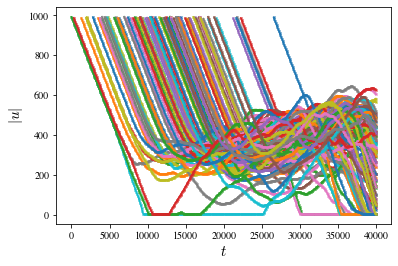

In [5]:
# %matplotlib ipympl
from matplotlib.patches import Rectangle
fig, ax = plt.subplots()
# rect = Rectangle((3000*0.8-250, 0), 500, 0.3, color='gray', alpha=0.3) 
# ax.add_patch(rect)

for a in tqdm.trange(-100,-1):
    ax.plot(t[:],x[:,a][:], marker = 'x', markersize = 2)
    # ax.plot(x[:,a][:],e[:,a][:], marker = 'x', markersize = 2)

# plt.ylim(981,1000)
plt.xlabel(r'$t$', fontsize=15)
plt.ylabel(r'$|u|$', fontsize=15)
